## Classification using Deep neural network

Binary classification using Deep Neural Networks Example: Classify movie reviews into 
positive" reviews and "negative" reviews, just based on the text content of the reviews. Use 
IMDB dataset 

In [17]:
import pandas as pd

In [18]:
df = pd.read_csv('../DL/Assignment02/imdb_data.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [19]:
X = df["review"]
y = df["sentiment"]

from sklearn.model_selection import train_test_split
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.3, random_state=42)

In [20]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train_raw)
y_test = encoder.transform(y_test_raw)

In [21]:
VOCAB_SIZE = 10000
MAX_LEN    = 200

from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')


In [22]:
tokenizer.fit_on_texts(X_train_raw)
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq = tokenizer.texts_to_sequences(X_test_raw)

In [23]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating="post")
X_test = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating="post")

In [26]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten   

model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8005 - loss: 0.4152 - val_accuracy: 0.8594 - val_loss: 0.3180
Epoch 2/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9623 - loss: 0.1068 - val_accuracy: 0.8434 - val_loss: 0.4508
Epoch 3/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9954 - loss: 0.0163 - val_accuracy: 0.8431 - val_loss: 0.6255
Epoch 4/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9997 - loss: 0.0023 - val_accuracy: 0.8480 - val_loss: 0.7272
Epoch 5/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 1.0000 - loss: 2.3222e-04 - val_accuracy: 0.8500 - val_loss: 0.7729
Epoch 6/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 6.5647e-05 - val_accuracy: 0.8497 - val_loss: 0.8077
Epoch 7/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 3.1084e-05 - val_accuracy: 0.8500 - val_loss: 0.8419
Epoch 8/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 1.0000 - loss: 1.6693e-05

In [29]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=1)
print("Test Accuracy : ", accuracy)
print("Test Loss : ", loss)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8315 - loss: 0.7545
Test Accuracy :  0.8314666748046875
Test Loss :  0.7544800639152527


In [30]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [32]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[6201, 1210],
       [1318, 6271]])

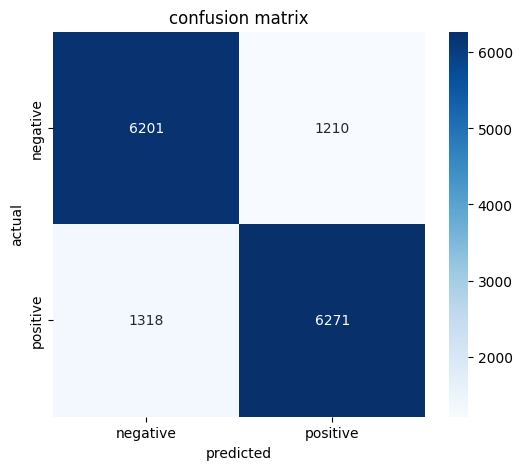

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()